In [3]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

# # # # # # # # # # # 
# tag = '2022041804_04'
# tag = '2022041807_a03' 
tag = '2022041809_a04'
which_fp_coods = '2022050214_BLrdkit_2000n_test_32neigh_mindist0pt1'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
p = f'/home/kat/Repos/SALSA/results/umap_dfs/{which_fp_coods}.csv'

## 1) Load coords.

In [11]:
import pandas as pd
df = pd.read_csv(p)
df = df[['Smiles','Label','Atype','x','y']]
df

,Smiles,Label,Atype,x,y
0,CC(C)CC(NC(=O)C(CC(C)C)NC(=O)C1NC(=O)NC(=O)C1F...,0,Anc,5.334035,13.158565
1,O=C(Nc1cccc(C(F)(F)F)c1)c1nscc1NCCc1ccc2c(c1)OCO2,1,Anc,-2.561136,5.725597
2,c1ccc(-c2nnc(N3CCOCC3)c3ccccc23)cc1,2,Anc,-5.071814,10.168095
3,NC1(C(=O)O)CCc2cc(N(CCCl)CCCl)ccc2C1,3,Anc,4.021219,8.798464
4,Cc1ncoc1-c1nnc(SCCCNC2CC3CC3(c3ccccc3)C2)n1C,4,Anc,7.562255,12.179224
...,...,...,...,...,...
11995,CC(Cn1nnc2ccccc2c1=O)C(=O)NCC1CCC(C(=O)O)CC1,1999,Aug,-1.426289,11.247730
11996,Cc1ccc2c(=O)n(CCC(=O)NCC3CCC(C(=O)O)CC3)nnc2c1,1999,Aug,-1.368940,11.313258
11997,NC1(CNC(=O)CCn2nnc3ccccc3c2=O)CCC(C(=O)O)CC1,1999,Aug,-1.380255,11.292233
11998,CC(NC(=O)CCn1nnc2ccccc2c1=O)C1CCC(C(=O)O)CC1,1999,Aug,-1.345128,11.324525


## 2) Get anc-aug map.

In [9]:
mdir = '/home/kat/Repos/SALSA/data/model_ready/'

anc_path = f'{mdir}{which_test}/test/anchor_smiles.csv'
aug_path = f'{mdir}{which_test}/test/augmented_smiles.csv'   
# ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)

## 3) Get anc-aug distances.

In [ ]:
from tqdm.notebook import tqdm
from scipy.spatial import distance
from itertools import combinations as combo

anc_aug_dists = []
far = []
for anc,augs in tqdm(anc_map.items(), total=len(anc_map)):
    augs = list(augs)
    augs.pop(0)
    
    coords_anc = latents[anc]    
    for aug in augs:
        latent_aug = latents[aug]
        d = distance.euclidean(latent_anc, latent_aug)
        if d > 1:
            far.append(anc)
        anc_aug_dists.append(d)

In [5]:
from eval_functions import *

which_test = '01'
test_ood = False
test_extended = False

which_train = '01'
samp_size = 2000
n_epochs = 30

eval_bs = 48
use_cuda = True
empty_cuda = True
cuda_ids = [0,1,2,3]

df, latents = get_df_and_latents(tag, which_train, which_test, test_ood, test_extended,
                                 samp_size, eval_bs, n_epochs, use_cuda, empty_cuda, cuda_ids)

mdir = '/home/kat/Repos/SALSA/data/model_ready/'

anc_path = f'{mdir}{which_test}/test/anchor_smiles.csv'
aug_path = f'{mdir}{which_test}/test/augmented_smiles.csv'   
# ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)



Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041809_a04/29.pt!
Loaded evaluation data from /home/kat/Repos/SALSA/data/model_ready/01/test/anchor_smiles.csv!


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

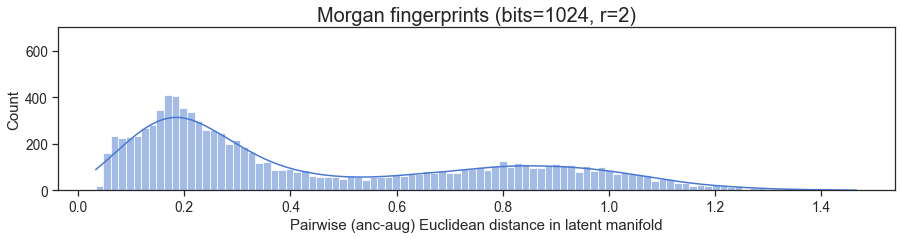

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

# t = 'SALSA (Graph-constrastive autoencoder)'
# t = 'Contrastive encoder'
# t = 'Vanilla autoencoder'
t = 'Morgan fingerprints (bits=1024, r=2)'


plt.figure(figsize=(15,3))
plt.title(t,fontsize=20)
plt.xlabel('Pairwise (anc-aug) Euclidean distance in latent manifold')

plt.ylim(0,700)
# plt.ylim(0,1100)

sns.histplot(anc_aug_dists, bins=100, kde=True)
# plt.savefig()
plt.show()